In [75]:
from pathlib import Path
import tomli
import numpy as np
import geopandas as gpd
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import imod
from shapely.geometry import Point, LineString, Polygon
from rasterio.features import rasterize
import contextily as cx
from rasterstats import zonal_stats

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

# TWEE KEER DRAAIEN: voor scenario REF en scenario SCEN

In [76]:
# scenario: "REF" of "SCEN"
# kD_dagen: kD raster gebaseerd op 5 dagen of 20 dagen. besloten 20 dagen.
# factor_lengte_weerstand: L = 2xl of L = 4xl (gekozen voor 4)
# weerstand_uit_gemiddelde_afstand: True: weerstand op basis van gemiddelde afstand False: weerstand per cel en dan gemiddelde
# berging_op_maaiveld: standaard stond op 10.0. om afvoerpieken bij buien te verlagen: 25.0
# infiltratie_factor: 1.0: conform grondwaterzakboekje.  om afvoerpieken bij buien te verlagen: 4.0
# use_amigo_init_gws: True initiële grondwaterstand gebaseerd op gegeven datum

# REF of SCEN los van elkaar draaien. Zo komen we op de volgende lijst van run+scenario (los van elkaar draaien!!!)

# run_name, scenario = "OY_0_kD5_L4", "REF"
# run_name, scenario = "OY_0_kD5_L4", "SCEN"
# run_name, scenario = "OY_1_kD20_L4", "REF"
# run_name, scenario = "OY_1_kD20_L4", "SCEN"
# run_name, scenario = "OY_2_kD20_L2", "REF"
# run_name, scenario = "OY_2_kD20_L2", "SCEN"
# run_name, scenario = "OY_3_kD20_L4_W", "REF"
# run_name, scenario = "OY_3_kD20_L4_W", "SCEN"
# run_name, scenario = "OY_4_kD20_L4_W_InfMax", "REF"
# run_name, scenario = "OY_4_kD20_L4_W_InfMax", "SCEN"
# run_name, scenario = "OY_5_kD20_L4_W_InfMax_InitGWS", "REF"
# run_name, scenario = "OY_5_kD20_L4_W_InfMax_InitGWS", "SCEN"

# SIMULATIES TBV ONDERZOEK INLOOPTIJD ICM INITIËLE GRONDWATERSTAND
# run_name, scenario = "OY_5_kD20_L4_W_InfMax_InitGWS_20140101_20160930", "REF"
# run_name, scenario = "OY_5_kD20_L4_W_InfMax_InitGWS_20130101_20160930", "REF"
run_name, scenario = "OY_5_kD20_L4_W_InfMax_InitGWS_20120401_20160930", "REF"

In [77]:
def read_toml(run_name):
    with open(f"runs_toml//{run_name}.toml", "rb") as f:
        data = tomli.load(f)
        data["amigo_gws_init_date"] = pd.Timestamp(data["amigo_gws_init_date"])
    return data.values()

kD_dagen, factor_lengte_weerstand, weerstand_uit_gemiddelde_afstand, \
    berging_op_maaiveld, infiltratie_factor, use_amigo_init_gws, amigo_gws_init_date \
        = read_toml(run_name)

#### Basisdata:
- Afwateringseenheden: afwateringseenheden.gpkg
- Pilotgebieden: gebieden.gpkg
- Leggerwatergangen: watergang.gpkg

In [78]:
# INPUT vanuit WRIJ voor RR unpaved methode
main_dir = Path("D:\\153961_Oude_IJssel")
dir_input = Path(main_dir, "WRIJ_RR_Unpaved_methode_02_input")
dir_input_basis_data = dir_input / "basisdata"

project_areas_path = dir_input_basis_data / "gebieden.gpkg"
path_watergang = dir_input_basis_data / "watergang.gpkg"
path_afwateringseenheden = dir_input_basis_data / "afwateringseenheden.gpkg"

project_areas = gpd.read_file(project_areas_path, layer="gebieden")
watergang = gpd.read_file(path_watergang)
afwateringseenheden = gpd.read_file(path_afwateringseenheden)

In [79]:
# OUTPUT location om tussenresultaten weg te schrijven
dir_rr_data_scenarios = Path(main_dir, f"WRIJ_RR_Unpaved_methode_02_input\\rr_data_scenarios\\{run_name}")
dir_rr_data_scenarios.mkdir(parents=True, exist_ok=True)
Path(dir_rr_data_scenarios, scenario).mkdir(parents=True, exist_ok=True)

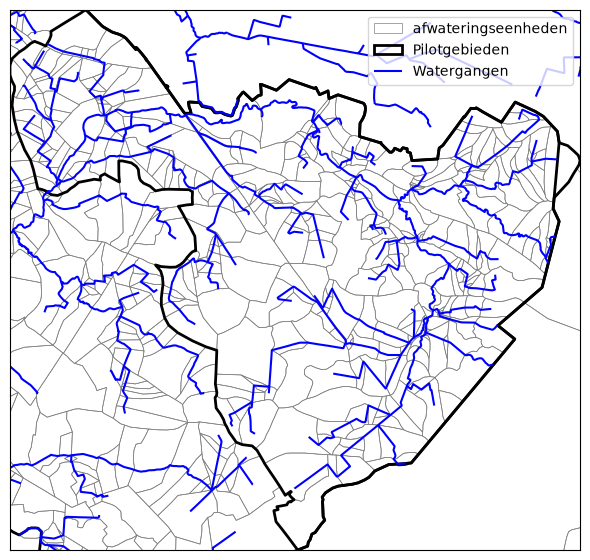

In [80]:
# kaartje voor pilot gebied X
fig, ax = plt.subplots(figsize=(6, 6))
xmin,ymin,xmax,ymax = project_areas.iloc[3].geometry.bounds
ax.set_xlim(round(xmin), round(xmax))
ax.set_ylim(round(ymin), round(ymax))
afwateringseenheden.plot(ax=ax, facecolor='none', edgecolor='grey', label='afwateringseenheden', linewidth=0.5)
project_areas.plot(ax=ax, facecolor='none', edgecolor='black', label='Pilotgebieden',linewidth=2)
watergang.plot(ax=ax, facecolor='none', edgecolor="blue", label='Watergangen')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.legend()
# cx.add_basemap(ax, crs=28992, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)
fig.tight_layout()

#### Data vanuit AMIGO

Overige data:
- LANDGEBRUIK.ASC
- BODEMKAART.ASC
- MV25_FILL.ASC
- REF_STORAGE_ON_LAND_MM.ASC --> Niet meenemen. Wordt als parameter opgegeven in de toml
- SCEN_STORAGE_ON_LAND_MM.ASC --> Niet meenemen. Wordt als parameter opgegeven in de toml
- MAXIMALE_INFILTRATIE_CAPACITEIT_MMUUR.ASC --> Niet meenemen. MAX_INF op basis van bodemtype en grondwaterzakboekje (zie verderop)
- WEERSTANDEN_TEGEN_OPPERVLAKKIGE_AFTROMING_D.ASC --> Niet meenemen. Gekozen voor 0.1 dagen

Effectieve kD (5 of 10 dagen? -> uiteindelijk is gekozen voor 20 dagen!)
- KD_EFF_L1-14 met correctie voor tussenliggende weerstand van 5 dagen(?). -> Dit wordt nog nader onderzocht. 
- kD is bepaald voor alle lagen samen door de kD's van alle lagen op te tellen.

Ontwateringsmiddelen (onderstaande lijst voor REF, bij SCEN is BUISDRAINAGE_WINTER en BUISDRAINAGE_ZOMER)
- REF_ONTWATERINGSMIDDELENWEERSTANDTOP10.ASC
- REF_ONTWATERINGSMIDDELENWEERSTANDLEGGER_ZOMER.ASC
- REF_ONTWATERINGSMIDDELENWEERSTANDLEGGER_WINTER.ASC
- REF_ONTWATERINGSMIDDELENWEERSTANDBUISDRAINAGE.ASC (bij SCEN _WINTER en _ZOMER)
- REF_ONTWATERINGSMIDDELENLEVELTOP10.ASC
- REF_ONTWATERINGSMIDDELENLEVELLEGGER_ZOMER.ASC
- REF_ONTWATERINGSMIDDELENLEVELLEGGER_WINTER.ASC
- REF_ONTWATERINGSMIDDELENLEVELBUISDRAINAGE.ASC (bij SCEN _WINTER en _ZOMER)
- REF_ONTWATERINGSMIDDELENCONDUCTANCETOP10.ASC
- REF_ONTWATERINGSMIDDELENCONDUCTANCELEGGER_ZOMER.ASC
- REF_ONTWATERINGSMIDDELENCONDUCTANCELEGGER_WINTER.ASC
- REF_ONTWATERINGSMIDDELENCONDUCTANCEBUISDRAINAGE.ASC (bij SCEN _WINTER en _ZOMER)

Flux onderrand (kwel/wegzijging) --> directe input voor RR_input naar RR_model (geen vertaling nodig)
- REF_FLUX_L1L2_YYYYMM_MMD.ASC (tijdgebonden: YYYYMM in mm/dag)


In [81]:
path_dir_data = Path(main_dir, "WRIJ_RR_Unpaved_methode_01_data")
path_oplevering_amigo = Path(path_dir_data, "20260508_AMIGOtifs_output")
path_oplevering_grondwaterstand = Path(path_dir_data, "20260717_Grondwaterstanden_head1")

In [82]:
def read_amigo_asc(path_oplevering_amigo, scenario):

    """

    Read AMIGO .ASC files and return as xarray DataArray.
    
    """

    # Choose correct KD_EFF_L1-14 file based on kD_dagen (from toml)
    if kD_dagen == 5:
        path_kd_eff_l1_14 = Path(path_oplevering_amigo, "02 Effectieve kD", "5dagen", "KD_EFF_L1-14.ASC")
    elif kD_dagen == 20:
        path_kd_eff_l1_14 = Path(path_oplevering_amigo, "02 Effectieve kD", "20dagen", "KD_EFF_L1-14_C20D_KD1.ASC")

    # Load overige AMIGO .ASC files
    path_overig = Path(path_oplevering_amigo, "04_Overig")
    path_landgebruik = Path(path_overig, "LANDGEBRUIK.ASC")
    path_bodemkaart = Path(path_overig, "BODEMKAART.ASC")
    path_maaiveld = Path(path_overig, "MV25_FILL.ASC")

    # Load AMIGO .ASC files for drainage systems (ontwateringsmiddelen) - LEGGER
    path_ontwateringsmiddelen = Path(path_oplevering_amigo, "03_Ontwateringsmiddelen")
    path_legger_weerstand_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDLEGGER_ZOMER.ASC")
    path_legger_weerstand_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDLEGGER_WINTER.ASC")
    path_legger_level_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELLEGGER_ZOMER.ASC")
    path_legger_level_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELLEGGER_WINTER.ASC")
    path_legger_conductance_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCELEGGER_ZOMER.ASC")
    path_legger_conductance_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCELEGGER_WINTER.ASC")

    # Load AMIGO .ASC files for drainage systems (ontwateringsmiddelen) - TOP10
    path_top10_level = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELTOP10.ASC")
    path_top10_weerstand = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDTOP10.ASC")
    path_top10_conductance = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCETOP10.ASC")

    # Load AMIGO .ASC file for initial groundwater level (if use_amigo_init_gws is True in toml)
    if use_amigo_init_gws:
        path_initial_gws_head1 = Path(path_oplevering_grondwaterstand, scenario, f"{scenario}_HEAD_L1_{amigo_gws_init_date.strftime('%Y%m')}.ASC")
    else:
        path_initial_gws_head1 = None

    # Load AMIGO .ASC files for drainage systems (ontwateringsmiddelen) - BUISDRAINAGE
    if scenario == "REF":
        path_buisdrainage_level_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELBUISDRAINAGE.ASC")
        path_buisdrainage_level_winter = path_buisdrainage_level_zomer
        path_buisdrainage_weerstand_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDBUISDRAINAGE.ASC")
        path_buisdrainage_weerstand_winter = path_buisdrainage_weerstand_zomer
        path_buisdrainage_conductance_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCEBUISDRAINAGE.ASC")
        path_buisdrainage_conductance_winter = path_buisdrainage_conductance_zomer
    else:
        path_buisdrainage_level_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELBUISDRAINAGE_ZOMER.ASC")
        path_buisdrainage_level_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENLEVELBUISDRAINAGE_WINTER.ASC")
        path_buisdrainage_weerstand_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDBUISDRAINAGE_ZOMER.ASC")
        path_buisdrainage_weerstand_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENWEERSTANDBUISDRAINAGE_WINTER.ASC")
        path_buisdrainage_conductance_zomer = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCEBUISDRAINAGE_ZOMER.ASC")
        path_buisdrainage_conductance_winter = Path(path_ontwateringsmiddelen, scenario, f"{scenario}_ONTWATERINGSMIDDELENCONDUCTANCEBUISDRAINAGE_WINTER.ASC")

    # create a dictionary of paths to all the AMIGO .ASC files
    dict_paths = {
        "kD_eff_L1_14": path_kd_eff_l1_14,
        "landgebruik": path_landgebruik,
        "bodemkaart": path_bodemkaart,
        "maaiveld": path_maaiveld,
        "legger_weerstand_zomer": path_legger_weerstand_zomer,
        "legger_weerstand_winter": path_legger_weerstand_winter,
        "legger_level_zomer": path_legger_level_zomer,
        "legger_level_winter": path_legger_level_winter,
        "legger_conductance_zomer": path_legger_conductance_zomer,
        "legger_conductance_winter": path_legger_conductance_winter,
        "top10_level": path_top10_level,
        "top10_weerstand": path_top10_weerstand,
        "top10_conductance": path_top10_conductance,
        "buisdrainage_level_zomer": path_buisdrainage_level_zomer,
        "buisdrainage_level_winter": path_buisdrainage_level_winter,
        "buisdrainage_weerstand_zomer": path_buisdrainage_weerstand_zomer,
        "buisdrainage_weerstand_winter": path_buisdrainage_weerstand_winter,
        "buisdrainage_conductance_zomer": path_buisdrainage_conductance_zomer,
        "buisdrainage_conductance_winter": path_buisdrainage_conductance_winter,
        "initial_gws_head1": path_initial_gws_head1,
    }

    # Read all the .ASC files into xarray DataArrays and merge them into a single xarray Dataset
    arrays = []
    for name, path_file in dict_paths.items():
        if path_file is None:
            continue
        da = xr.open_dataarray(path_file, engine="rasterio").squeeze()
        da.name = name
        arrays.append(da)
        
    ds = xr.merge(arrays)

    # Apply a minimum value of 0.1 to the kD_eff_L1_14 variable to avoid negative or zero values
    ds["kD_eff_L1_14"] = ds["kD_eff_L1_14"].where(ds["kD_eff_L1_14"] > 0.1, other=0.1)

    # Fill NaN values in landgebruik and bodemkaart with -1 and convert to integer type
    ds["landgebruik"] = ds.landgebruik.fillna(-1).astype(int)
    ds["bodemkaart"] = ds.bodemkaart.fillna(-1).astype(int)

    # Reverse the y-axis to match the original orientation of the .ASC files
    ds = ds.isel(y=slice(None, None, -1))

    # set the crs of the dataset to EPSG:28992 (Amersfoort / RD New)
    ds = ds.rio.write_crs("EPSG:28992")

    # Return the final xarray Dataset
    return ds

In [83]:
# Read AMIGO .ASC files and return as xarray Dataset
ds = read_amigo_asc(path_oplevering_amigo, scenario=scenario)

#### Kolommen resulterende geopackage (CSV)

GFEIDENT --> uit afwateringseenheden  
SUBGEBIED --> volgt uit maaiveldanalyse  
ID_RR_KNOOP --> GFEIDENT + '_' + SUBGEBIED  
xcoor --> gemiddelde x-coördinaat van alle cellen van dit subgebied  
ycoor --> gemiddelde y-coördinaat van alle cellen van dit subgebied  
Area_RR_unpaved_m2 --> sum of rastercells * 25m * 25m  
SurfaceLevel_mNAP --> mediaan van maaiveldhoogten voor de individuele cellen binnen SUBGEBIED

SUBMODEL --> REF_WINTER  
CapSimSoilType --> meest voorkomende soiltype  
StorageOnLand_mm --> wordt als parameter opgegeven in de toml  
InfiltrationCapacity_mmph --> wordt berekend o.b.v. kentallen grondwaterzakboekje * infiltratie_factor uit toml  

SurfaceOverlandFlowResistance_d  
FirstDrainLevel_mNAP  
FirstDrainResistance_d  
SecondDrainLevel_mNAP  
SecondDrainResistance_d  
ThirdDrainLevel_mNAP  
ThirdDrainResistance_d  
OpenWaterLevelBoundary_mNAP  
OpenWaterDrainResistance_d  
OpenWaterHorizontalInflowResistance_d  
InitialGroundwaterLevel_mBelowSurface  
LayerThickness_m  
MaximumAllowedLevel_mNAP  
MeteoStationName  
AreaAdjustmentFactor  
CropType  
CropType_tekst  

#### Subgebieden definiëren
Subgebieden definiëren op basis van maaiveldbestand MV25_FILL.asc:
- Per afwateringseenheid 5% percentiel maaiveldhoogte bepalen (5%perc)
- Maaiveldniveau < 5%perc+0,5m = subgebied Laag (blauw op kaart)
- Maaiveldniveau < 5%perc+2m = subgebied Middel (geel op kaart)
- Maaiveldniveau > 5%perc+2m = subgebied Hoog (rood op kaart)

Geen criteria wat betreft minimaal aantal punten per subgebied

In [84]:
# add GFEIDENT_id to afwateringseenheden gdf for rasterization
afwateringseenheden["GFEIDENT_id"] = afwateringseenheden.index

# rasterize afwateringseenheden based on column "GFEIDENT_id", use shape of ds["maaiveld"] as template
da_afwateringseenheden = imod.prepare.rasterize(
    geodataframe=afwateringseenheden, 
    column="GFEIDENT_id", 
    like=ds["maaiveld"]
)

# Fill NaN values in the rasterized afwateringseenheden with -1 and convert to integer type
ds["GFEIDENT_id"] = da_afwateringseenheden.fillna(-1).astype(int)

# rasterize project areas (pilotgebieden) based on column "area_id", use shape of ds["maaiveld"] as template
project_areas_sel = project_areas.iloc[1:]
da_project_areas_sel = imod.prepare.rasterize(
    geodataframe=project_areas_sel, 
    column="area_id",
    like=ds["maaiveld"]
)

# Fill NaN values in the rasterized project areas with -1 and convert to integer type
ds["pilot_areas"] = da_project_areas_sel.fillna(-1).astype(int)

In [85]:
# calculate the 5th percentile of the maaiveld values within each afwateringseenheden polygon
zs = zonal_stats(
    afwateringseenheden.geometry,
    ds["maaiveld"].values,
    affine=ds["maaiveld"].rio.transform(),
    stats=["percentile_5"],
    all_toughed=False,
    no_data=np.nan
)

# add the 5th percentile values to the afwateringseenheden GeoDataFrame
afwateringseenheden["maaiveld_perc05"] = [z["percentile_5"] for z in zs]

# rasterize the 5th percentile maaiveld values based on column "maaiveld_perc05", use shape of ds["maaiveld"] as template
maaiveld_perc05 = imod.prepare.rasterize(
    geodataframe=afwateringseenheden, 
    column="maaiveld_perc05",
    like=ds["maaiveld"]
)

# Add the rasterized 5th percentile maaiveld values to the xarray Dataset
ds["maaiveld_afw_eenh_perc05"] = maaiveld_perc05.copy()

In [86]:
# create a new variable "hoog_middel_laag" in the xarray Dataset based
ds["hoog_middel_laag"] = ds["maaiveld_afw_eenh_perc05"].copy()

# create masks for the different categories of maaiveld (laag, middel, hoog) based on the 5th percentile maaiveld values
mask_maaiveld = ds["maaiveld"] > 0.0
mask_laag = ds["maaiveld"] <= ds["maaiveld_afw_eenh_perc05"] + 0.5
mask_middel_hoog = ds["maaiveld"] > ds["maaiveld_afw_eenh_perc05"] + 0.5
mask_hoog = ds["maaiveld"] > ds["maaiveld_afw_eenh_perc05"] + 2.0

# Assign values to the "hoog_middel_laag" variable based on the masks
ds["hoog_middel_laag"] = ds["hoog_middel_laag"].where(~mask_laag, 1)
ds["hoog_middel_laag"] = ds["hoog_middel_laag"].where(~mask_middel_hoog, 2)
ds["hoog_middel_laag"] = ds["hoog_middel_laag"].where(~mask_hoog, 3)
ds["hoog_middel_laag"] = ds["hoog_middel_laag"].where(mask_maaiveld)
ds["hoog_middel_laag"] = ds["hoog_middel_laag"].fillna(-1).astype(int)

# write the "hoog_middel_laag" variable to a GeoTIFF file
ds["hoog_middel_laag"].rio.write_crs(28992).rio.to_raster(Path(dir_input_basis_data, "hoog_middel_laag.tif"))

c:\Users\ROMN\git_projects\WRIJ_RR_Unpaved_methode\.venv\Lib\site-packages\xarray\core\duck_array_ops.py:277: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


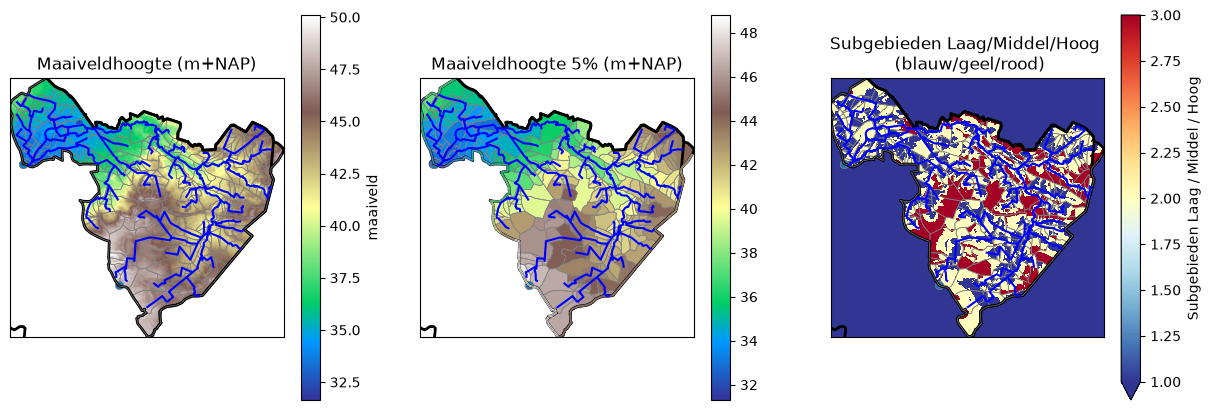

In [87]:
# Plot the results for a selected project area
sel_gebied = 3
project_area = project_areas.iloc[sel_gebied]

# kaartje voor pilot gebied 3
fig, axs = plt.subplots(1,3, figsize=(15,5))
xmin,ymin,xmax,ymax = project_area.geometry.bounds

# maaiveldhoogte
da_maaiveld = ds["maaiveld"].rio.clip([project_area.geometry])
da_maaiveld.plot(ax=axs[0], cmap="terrain", vmin=da_maaiveld.min(), vmax=da_maaiveld.max())
axs[0].set_title("Maaiveldhoogte (m+NAP)")

# maaiveldhoogte 5%
afw_eenh = afwateringseenheden.clip(project_area.geometry)
afw_eenh.plot(
    ax=axs[1], 
    column="maaiveld_perc05", 
    vmin=afw_eenh["maaiveld_perc05"].min(), 
    vmax=afw_eenh["maaiveld_perc05"].max(), 
    cmap="terrain", legend=True
)
axs[1].set_title("Maaiveldhoogte 5% (m+NAP)")

# maaiveldhoogte 5%
ds["hoog_middel_laag"].rio.clip([project_area.geometry]).plot(ax=axs[2], vmin=1, vmax=3, cmap="RdYlBu_r", 
                                                              cbar_kwargs={"label":"Subgebieden Laag / Middel / Hoog"})
axs[2].set_title("Subgebieden Laag/Middel/Hoog \n (blauw/geel/rood)")

for ax in axs:
    afwateringseenheden.clip(project_area.geometry).plot(ax=ax, facecolor='none', edgecolor='grey', label='afwateringseenheden', linewidth=0.5)
    project_areas.plot(ax=ax, facecolor='none', edgecolor='black', label='Pilotgebieden', linewidth=2)
    watergang.clip(project_area.geometry).plot(ax=ax, facecolor='none', edgecolor="blue", label='Watergangen')
    ax.set_xlim(round(xmin), round(xmax))
    ax.set_ylim(round(ymin), round(ymax))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

#### Onderscheid Legger, Top10, Buisdrainage
- Blauw: Legger watergangen
- Groen: Top10 watergangen
- Oranje: Buisdrainage

In [88]:
# Add binary variables for the location of the drainage systems to the xarray Dataset
ds["legger"] = (ds["legger_weerstand_zomer"] > 0.0).astype(int)
ds["top10"] = (ds["top10_weerstand"] > 0.0).astype(int)
ds["buisdrainage"] = (ds["buisdrainage_weerstand_zomer"] > 0.0).astype(int)

In [89]:
# write the xarray Dataset to a NetCDF file
path_amigo_nc = Path(dir_rr_data_scenarios, scenario, "amigo_rasters.nc")
ds.to_netcdf(path_amigo_nc)

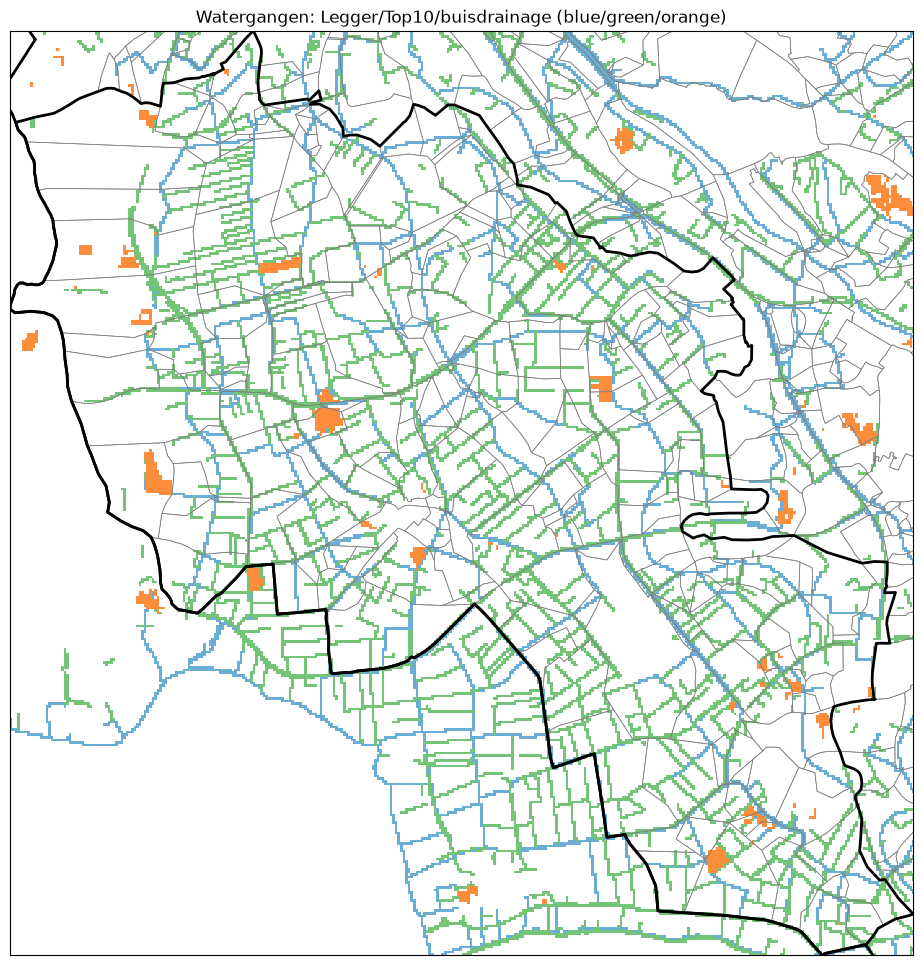

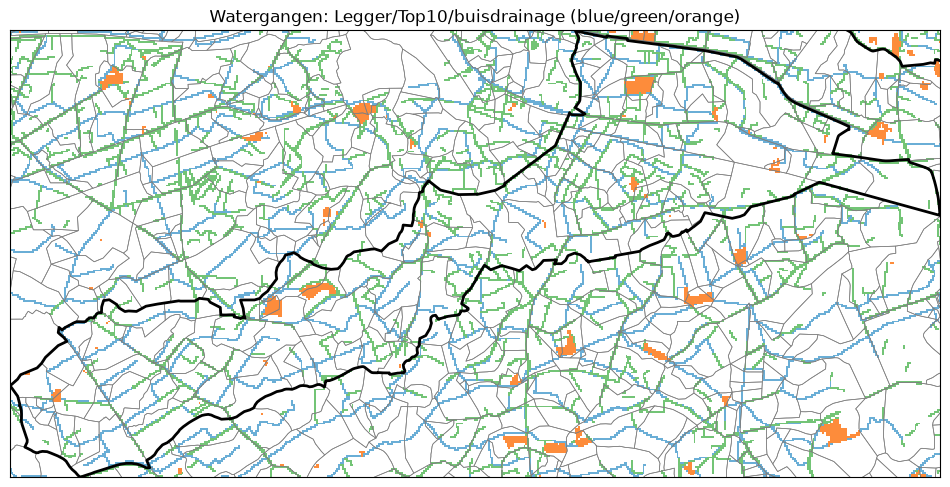

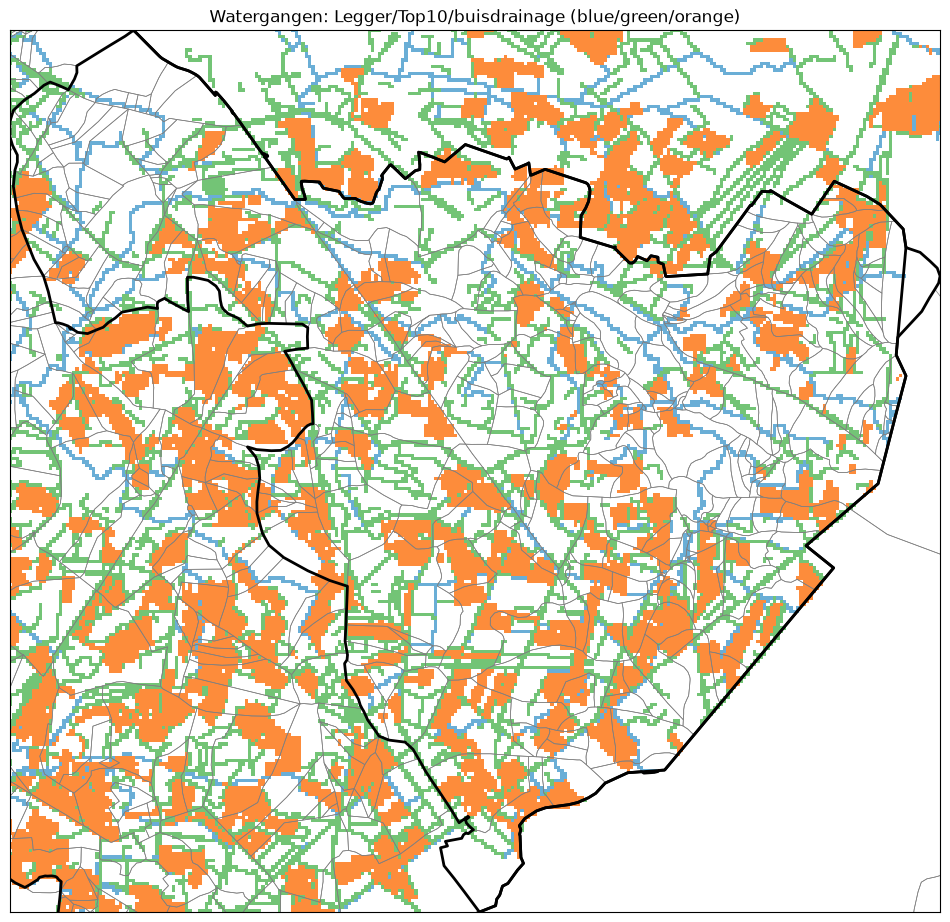

In [90]:
# Create a function to create a figure showing the location of the drainage systems (legger, top10, buisdrainage) for a selected project area
def create_figure_legger_top10_buisdrainage(sel_gebied):

    # get the selected project area
    project_area = project_areas.iloc[sel_gebied]

    # kaartje voor pilot gebied X
    fig, ax = plt.subplots(figsize=(12,12))
    xmin,ymin,xmax,ymax = project_area.geometry.bounds

    # Plot the drainage systems (legger, top10, buisdrainage) for the selected project area
    ds["legger"].where(ds["legger"] != 0).plot(cmap="Blues", add_colorbar=False)
    ds["top10"].where(ds["top10"] != 0).plot(cmap="Greens", add_colorbar=False)
    ds["buisdrainage"].where(ds["buisdrainage"] != 0).plot(cmap="Oranges", add_colorbar=False)

    # plot the afwateringseenheden and project areas on top of the drainage systems
    afwateringseenheden.plot(ax=ax, facecolor='none', edgecolor='grey', label='afwateringseenheden', linewidth=0.5)
    project_areas.plot(ax=ax, facecolor='none', edgecolor='black', label='Pilotgebieden',linewidth=2)
    # watergang.plot(ax=ax, facecolor='none', edgecolor="blue", label='Watergangen')

    # set plot settings and add basemap
    ax.set_title("Watergangen: Legger/Top10/buisdrainage (blue/green/orange)")
    ax.set_xlim(round(xmin), round(xmax))
    ax.set_ylim(round(ymin), round(ymax))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # cx.add_basemap(ax, crs=28992, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)

    # save the figure to a PNG file in the dir_input directory
    fig.savefig(Path(dir_input, f"legger_top10_buisdrainage_gebied_{sel_gebied}.png"))

# Create figures for the drainage systems for each selected project area
for sel_gebied in [1,2,3]:
    create_figure_legger_top10_buisdrainage(sel_gebied)

#### Opdeling subgebieden, Maaiveld, landgebruik, bodemtype, infiltratie en andere standaardgetallen
Voor alle RR inputparameters worden de waarden geaggregeerd van 25 x 25 m naar de SUBGEBIEDEN. Deze waarden worden gekoppeld aan 1 van de punten van een SUBGEBIED (willekeurig)

Algemeen:
- Maaiveldhoogte per SUBGEBIED = mediaan van maaiveldhoogten voor de individuele cellen binnen SUBGEBIED
- Landgebruik per SUBGEBIED = meest voorkomende landgebruik binnen SUBGEBIED
- Bodemtype per SUBGEBIED = meest voorkomende bodemtype binnen SUBGEBIED

In [91]:
# convert the xarray Dataset to a pandas DataFrame and reset the index
df = ds.to_dataframe().reset_index()

# select only the columns with a afwateringseenheid id (GFEIDENT_id) and subgebied (hoog_middel_laag)
df = df.loc[(df["GFEIDENT_id"] >= 0) & (df["hoog_middel_laag"] >= 0)]

# Groupby afwateringseenheid en subgebied (laag/middel/hoog) (double-index) -> to be used for calculating parameters per subgebied
df_grouped_gfeident_id_subgebied = df.groupby(["GFEIDENT_id", "hoog_middel_laag"])

In [92]:
# Calculate the median of the maaiveld (and possibly initial groundwater level) for each subgebied (laag/middel/hoog) within each afwateringseenheid
if use_amigo_init_gws:
    df_result = df_grouped_gfeident_id_subgebied[["maaiveld", "initial_gws_head1"]].median().round(3)
else:
    df_result = df_grouped_gfeident_id_subgebied[["maaiveld"]].median().round(3)

# Toevoegen code afwateringseenheid, geometry en code subgebied (RR-code) and transform to GeoDataFrame
df_result = df_result.reset_index().merge(afwateringseenheden[["GFEIDENT", "GFEIDENT_id", "geometry"]], on="GFEIDENT_id", how="left")
gdf = gpd.GeoDataFrame(df_result, geometry="geometry", crs=ds.rio.crs)
gdf["hoog_middel_laag_str"] = df_result["hoog_middel_laag"].map({1: 'laag', 2: 'middel', 3: 'hoog'})
gdf["RR_code"] = gdf.apply(lambda x: f"{x['GFEIDENT']}_{x['hoog_middel_laag_str']}", axis=1)

# Set the index of the gdf to be a multi-index of afwateringseenheid id (GFEIDENT_id) and subgebied (hoog_middel_laag)
gdf = gdf.set_index(["GFEIDENT_id", "hoog_middel_laag"])

# Select the relevant columns for the gdf (with or without initial groundwater level)
if use_amigo_init_gws:
    gdf = gdf[["GFEIDENT", "hoog_middel_laag_str", "RR_code", "maaiveld", "initial_gws_head1", "geometry"]]
else:
    gdf = gdf[["GFEIDENT", "hoog_middel_laag_str", "RR_code", "maaiveld", "geometry"]]

In [93]:
# landgebruik: meest voorkomende waarde per afwateringseenheid en subgebied
gdf["landgebruik"] = df_grouped_gfeident_id_subgebied["landgebruik"].agg(lambda x: x.mode().iloc[0]).to_frame()

# vertaaltabel: vertaling amigo_crop_type naar sobek_rr crop_no 
vertaaltabel_landgebruik = [
    {"amigo_crop_nr": 1, "amigo_crop_type": "gras", "crop_type": "grass", "crop_no": 1},
    {"amigo_crop_nr": 2, "amigo_crop_type": "mais", "crop_type": "corn", "crop_no": 2},
    {"amigo_crop_nr": 3, "amigo_crop_type": "aardappelen", "crop_type": "potatoes", "crop_no": 3},
    {"amigo_crop_nr": 4, "amigo_crop_type": "bieten", "crop_type": "sugarbeet", "crop_no": 4},
    {"amigo_crop_nr": 5, "amigo_crop_type": "graan", "crop_type": "grain", "crop_no": 5},
    {"amigo_crop_nr": 6, "amigo_crop_type": "overige landbouwgewas", "crop_type": "miscellaneous", "crop_no": 6},
    {"amigo_crop_nr": 7, "amigo_crop_type": "niet-bewerkbare grond", "crop_type": "non-arable land", "crop_no": 7},
    {"amigo_crop_nr": 8, "amigo_crop_type": "kassen", "crop_type": "greenhouse area", "crop_no": 8},
    {"amigo_crop_nr": 9, "amigo_crop_type": "boomgaard", "crop_type": "orchard", "crop_no": 9},
    {"amigo_crop_nr": 10, "amigo_crop_type": "bollen", "crop_type": "bulbous plants", "crop_no": 10},
    {"amigo_crop_nr": 11, "amigo_crop_type": "loofbos", "crop_type": "foliage forest", "crop_no": 11},
    {"amigo_crop_nr": 12, "amigo_crop_type": "naaldbos", "crop_type": "pine forest", "crop_no": 12},
    {"amigo_crop_nr": 13, "amigo_crop_type": "natte natuur", "crop_type": "nature", "crop_no": 13},
    {"amigo_crop_nr": 14, "amigo_crop_type": "droge natuur", "crop_type": "fallow", "crop_no": 13},
    {"amigo_crop_nr": 15, "amigo_crop_type": "onbekend", "crop_type": "onbekend", "crop_no": 1},                # !?!?
    {"amigo_crop_nr": 16, "amigo_crop_type": "zoet water", "crop_type": "open water", "crop_no": 1},            # OpenWater
    {"amigo_crop_nr": 17, "amigo_crop_type": "onbekend", "crop_type": "unknown", "crop_no": 1},                 # !?!?
    {"amigo_crop_nr": 18, "amigo_crop_type": "stedelijk bebouwd gebied", "crop_type": "flowers", "crop_no": 1}  # PAVED?
]

# Add a new column "landgebruik_no" to the gdf by mapping the "landgebruik" values to the corresponding "crop_no" values from the vertaaltabel_landgebruik
gdf["landgebruik_no"] = gdf["landgebruik"].map({l["amigo_crop_nr"]: l["crop_no"] for l in vertaaltabel_landgebruik})

In [94]:
# lees koppeltabel bodemkaart in: tabel opgesteld door Gerry Roelofs
path_koppeltabel_bodemkaart = Path(path_dir_data, "20260515_vertaaltabel_bodemcode\\Vertaaltabel_AMIGO_RR_5klassen.xlsx")
koppeltabel_bodemkaart = pd.read_excel(path_koppeltabel_bodemkaart)
bodemkaart_amigo2rr = koppeltabel_bodemkaart.set_index("AMIGO_SPU")["RR_PAWN"].to_dict()

# neem bodemtype uit AMIGO dat het meest voorkomt in de afwateringseenheid en subgebied
gdf["bodemkaart"] = df_grouped_gfeident_id_subgebied["bodemkaart"].agg(lambda x: x.mode().iloc[0]).to_frame()

# vertaal naar RR-codering
gdf["bodemtype_rr"] = gdf["bodemkaart"].map(bodemkaart_amigo2rr)

# Vul ontbrekende waarden in bodemtype_rr met de meest voorkomende waarde en zet om naar int
gdf["bodemtype_rr"] = gdf.bodemtype_rr.fillna(gdf.bodemtype_rr.mode().iloc[0]).astype(int)

In [95]:
# set berging op maaiveld to the value from the toml file (bergings_op_maaiveld)
gdf["berging_op_maaiveld_mm"] = berging_op_maaiveld

# set oppervlakkige_afstroming_weerstand_d to 0.1 (default value)
gdf["oppervlakkige_afstroming_weerstand_d"] = 0.1

MAXIMALE INFILTRATIE

Overwegend bodemtype en grondwaterzakboekje: Grondwater zakboekje 2011:
- Fijn zand: 0,3 m/d = 13 mm/u
- Fijn zand leem: 0,2 m/d = 8 mm/u
- Zavel licht: 0,3 m/d = 13 mm/u
- Matig zware klei: 0,02 m/d = 1 mm/u


In [96]:
# set infiltratie_mm_uur based on the koppeltabel_bodemkaart (categorie infiltratie) and the infiltratie_factor from the toml file
bodemkaart_amigo2categorieinfiltratie = koppeltabel_bodemkaart.set_index("AMIGO_SPU")["CATEGORIE_INFILTRATIE"].to_dict()

# set the infiltration rate (in mm/hour) based on the category of infiltration and the infiltratie_factor from the toml file
categorieinfiltratie2infiltratie_mm_uur = {
    "fijn zand": 13.0 * infiltratie_factor, 
    "fijn zand leem": 8.0 * infiltratie_factor, 
    "zavel licht": 13.0 * infiltratie_factor, 
    "matig zware klei": 1.0 * infiltratie_factor,
    "overig / veen": 5.0 * infiltratie_factor
}

# bereken infiltratie mm/uur op basis van categorieinfiltratie
gdf["categorie_infiltratie"] = gdf["bodemkaart"].map(bodemkaart_amigo2categorieinfiltratie)
gdf["infiltratie_mm_uur"] = gdf["categorie_infiltratie"].map(categorieinfiltratie2infiltratie_mm_uur)
gdf["infiltratie_mm_uur"] = gdf["infiltratie_mm_uur"].fillna(5.0)

- Drainageweerstand top10 = gemiddelde van top10 drainageweerstand van alle punten binnen SUBGEBIED
- Drainageweerstand buisdrain = gemiddelde van buisdrain drainageweerstand van alle punten binnen SUBGEBIED

#### Drainage naar LEGGERWATERGANG: 
- Voor elke cel BINNEN EEN SUBGEBIED wordt de afstand (kleine ‘l’) tot de dichtstbijzijnde legger watergang (blauw) uitgerekend. Elke legger cel (blauw) krijgt afstand NULL, overige cellen de waarde voor ‘l_legger’. Afwateringsgrenzen worden WEL gebruikt
- Voor elke cel in de ruimte wordt ook het level ZOMER en WINTER van de dichtstbijzijnde legger watergang afgelezen en verdeeld over alle punten in het gebied.
Daarmee krijgen niet enkel de blauwe cellen een level, maar het level wordt ruimtelijk gemaakt op basis van de dichtstbijzijnde legger watergang (zie voorbeeld pijl)
- Voor elke cel in de ruimte wordt ook een drainageweerstand voor ZOMER en WINTER bepaald. De blauwe cellen nemen 1 op 1 de waarde over uit de asc bestanden voor REF of SCEN (links). Voor cellen zonder legger watergang wordt de drainageweerstand tegen horizontale stroming naar de legger watergangen uitgerekend obv de formule linksonder. Waarbij: L = 4x kleine ‘l_legger’ en kD is de eerder bepaalde effectieve kD (voor het betreffende punt in de ruimte). De waarde die met de formule wordt berekend wordt zowel voor zomer als winter toegepast.

In [97]:
# selecteer punten uit df met leggerwatergangen en non-leggerwatergangen
columns_legger = ["GFEIDENT_id", "hoog_middel_laag", "x", "y", "legger_level_zomer", "legger_level_winter"]
df_legger = df[df["legger"] == 1][columns_legger]
df_non_legger = df[df["legger"] == 0][["GFEIDENT_id", "x", "y"]]

# zoek combinaties binnen afwateringseenheid (inner join)
# het resultaat is een dataframe met alle combinaties van non-legger punten en legger punten binnen dezelfde afwateringseenheid
df_legger_x = df_non_legger.merge(df_legger, on="GFEIDENT_id", how="inner", suffixes=("", "2"))

# bereken de afstand tussen legger cellen en non-legger cellen
df_legger_x["legger_afstand"] = np.sqrt((df_legger_x["x"] - df_legger_x["x2"])**2 + (df_legger_x["y"] - df_legger_x["y2"])**2)

# selecteer de kleinste afstand per non-legger punt, schrijf tussenresultaat weg naar geopackage
df_legger_x = df_legger_x.loc[df_legger_x.groupby(["x", "y"])["legger_afstand"].idxmin()]
gdf_legger_x = gpd.GeoDataFrame(df_legger_x, geometry=gpd.points_from_xy(df_legger_x.x, df_legger_x.y), crs=ds.rio.crs)
gdf_legger_x.to_file(Path(dir_rr_data_scenarios, scenario, "afstand_tot_leggerwatergang.gpkg"), layer="afstand_tot_leggerwatergang", driver="GPKG")

# voeg de afstand toe aan de originele dataframe, met ook de legger_level_zomer en legger_level_winter van de dichtstbijzijnde legger watergang
df_legger_x = df_legger_x[["x", "y", "legger_afstand", "legger_level_zomer", "legger_level_winter"]].copy()
df_legger_x.columns = ["x", "y", "legger_afstand", "legger_level_zomer_x", "legger_level_winter_x"]
df = df.merge(df_legger_x, on=["x", "y"], how="left")

In [98]:
# vul de legger levels voor zomer en winter aan met de waarden van de dichtstbijzijnde legger watergang (voor de non-legger punten)
df["legger_level_zomer"] = df["legger_level_zomer"].fillna(df["legger_level_zomer_x"])
df["legger_level_winter"] = df["legger_level_winter"].fillna(df["legger_level_winter_x"])

Resultaat legger:
- Level (legger_level) = mediaan van verspreide legger level van alle punten binnen SUBGEBIED (zomer/winter)
- Drainageweerstand (legger_weerstand) = gemiddelde van legger drainageweerstand van alle punten binnen SUBGEBIED (zomer/winter)

In [99]:
# bereken de drainageweerstand per subgebied o.b.v. de gemiddelde afstand tot een leggerwatergang (per subgebied) indien weerstand_uit_gemiddelde_afstand is True in the toml file
if weerstand_uit_gemiddelde_afstand:

    # bereken de gemiddelde afstand tot een leggerwatergang per afwateringseenheid en subgebied (laag/middel/hoog)
    df_legger_afstand = df.groupby(["GFEIDENT_id", "hoog_middel_laag"]).agg({"legger_afstand": "mean"}).reset_index()
    df_legger_afstand = df_legger_afstand.rename(columns={"legger_afstand": "legger_afstand_x"})

    # merge de gemiddelde afstand tot een leggerwatergang per afwateringseenheid en subgebied terug aan de originele dataframe
    df = df.merge(df_legger_afstand, how="left", on=["GFEIDENT_id", "hoog_middel_laag"])

    # vul/vervang de kolom leggen_afstand voor locaties waar de leggen_conductance_zomer is nan (dit zijn de non-legger cellen) met de gemiddelde afstand tot een leggerwatergang per subgebied
    df.loc[df["legger_conductance_zomer"].isna(), "legger_afstand"] = df["legger_afstand_x"]

# bereken weerstand conform W = L^2 / 12kD met L = 4xlegger_afstand
df["legger_weerstand_x"] = ((df["legger_afstand"]*factor_lengte_weerstand)**2.0) / (12.0 * df["kD_eff_L1_14"])

# vul de weerstanden van de kolommen legger_weerstand_zomer en legger_weerstand_winter aan voor de non-legger cellen
df["legger_weerstand_zomer"] = df["legger_weerstand_zomer"].fillna(df["legger_weerstand_x"])
df["legger_weerstand_winter"] = df["legger_weerstand_winter"].fillna(df["legger_weerstand_x"])

# schrijf de dataframe weg naar een geopackage
gdf_legger_weerstand = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=ds.rio.crs)
gdf_legger_weerstand.to_file(Path(dir_rr_data_scenarios, scenario, "legger_weerstand.gpkg"), layer="legger_weerstand", driver="GPKG")

# bereken de gemiddelde afstand tot een leggerwatergang, het mediane legger level voor zomer en winter, en de gemiddelde drainageweerstand voor zomer en winter per subgebied (laag/middel/hoog)
columns_legger = ["legger_afstand", "legger_level_zomer", "legger_level_winter", "legger_weerstand_zomer", "legger_weerstand_winter"]
gdf[columns_legger] = df.groupby(["GFEIDENT_id", "hoog_middel_laag"])[columns_legger].agg({
    "legger_afstand": "mean", 
    "legger_level_zomer": "median", 
    "legger_level_winter": "median", 
    "legger_weerstand_zomer": "mean", 
    "legger_weerstand_winter": "mean"
})

#### Drainage naar TOP10-WATERGANG: 
- Voor elke cel BINNEN EEN SUBGEBIED wordt de afstand (kleine ‘l’) tot de dichtstbijzijnde top10 watergang (groen) BINNEN DAT SUBGEBIED uitgerekend. Elke top10 cel (groen) krijgt afstand NULL, overige cellen de waarde voor ‘l_top10’. Afwateringsgrenzen worden WEL gebruikt.  
- Voor elke cel in de ruimte wordt ook het level ZOMER en WINTER van de dichtstbijzijnde top10 watergang afgelezen en verdeeld over alle punten in het SUBgebied. Daarmee krijgen niet enkel de groene cellen een level, maar het level wordt ruimtelijk gemaakt op basis van de dichtstbijzijnde top10 watergang (zie voorbeeld pijl)
- Voor elke cel in de ruimte wordt ook een drainageweerstand voor ZOMER en WINTER bepaald. De groene cellen nemen 1 op 1 de waarde over uit de asc bestanden voor REF of SCEN (links). Voor cellen zonder top10 watergang wordt de drainageweerstand tegen horizontale stroming naar de top10 watergangen uitgerekend obv de formule linksonder. W_h = L^2 / (12 * k_h * D) Waarbij: L = 4x kleine ‘l_top10’ en kD is de eerder bepaalde effectieve kD (voor het betreffende punt in de ruimte). De waarde die met de formule wordt berekend wordt zowel voor zomer als winter toegepast.
- drainageweerstand top10 = gemiddelde van top10 weerstand van alle punten binnen SUBGEBIED

In [100]:
# selecteer punten uit df met top10-watergangen en non-top10-watergangen
columns_top10 = ["GFEIDENT_id", "hoog_middel_laag", "x", "y", "top10_level"]
df_top10 = df[df["top10"] == 1][columns_top10]
df_non_top10 = df[df["top10"] == 0][["GFEIDENT_id", "hoog_middel_laag", "x", "y"]]

# zoek combinaties binnen afwateringseenheid (inner join)
# het resultaat is een dataframe met alle combinaties van non-top10 punten en top10 punten binnen dezelfde afwateringseenheid
df_top10_x = df_non_top10.merge(df_top10, on=["GFEIDENT_id", "hoog_middel_laag"], how="inner", suffixes=("", "2"))

# bereken de afstand tussen top10 cellen en non-top10 cellen
df_top10_x["top10_afstand"] = np.sqrt((df_top10_x["x"] - df_top10_x["x2"])**2 + (df_top10_x["y"] - df_top10_x["y2"])**2)

# selecteer de kleinste afstand per non-top10 punt, schrijf tussenresultaat weg naar geopackage
df_top10_x = df_top10_x.loc[df_top10_x.groupby(["x", "y"])["top10_afstand"].idxmin()]
gdf_top10_x = gpd.GeoDataFrame(df_top10_x, geometry=gpd.points_from_xy(df_top10_x.x, df_top10_x.y), crs=ds.rio.crs)
gdf_top10_x.to_file(Path(dir_rr_data_scenarios, scenario, "afstand_tot_top10-watergang.gpkg"), layer="afstand_tot_top10-watergang", driver="GPKG")

# voeg de afstand toe aan de originele dataframe
df = df.merge(df_top10_x[["x", "y", "top10_afstand"]], on=["x", "y"], how="left")

# bereken weerstand conform W = L^2 / 12kD met L = 4xtop10_afstand 
df["top10_weerstand_x"] = ((df["top10_afstand"]*factor_lengte_weerstand)**2.0) / (12.0 * df["kD_eff_L1_14"])

# vul de weerstanden van de kolom top10_weerstand aan voor de non-top10 cellent
df["top10_weerstand"] = df["top10_weerstand"].fillna(df["top10_weerstand_x"])

# schrijf de dataframe weg naar een geopackage
gdf_top10_weerstand = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=ds.rio.crs)
gdf_top10_weerstand.to_file(Path(dir_rr_data_scenarios, scenario, "top10_weerstand.gpkg"), layer="top10_weerstand", driver="GPKG")

Resultaat top10:
- Level (top10_level) = mediaan van verspreide top10 level van alle punten binnen SUBGEBIED (zomer/winter)
- Drainageweerstand (top10_weerstand) = gemiddelde van top10 drainageweerstand van alle punten binnen SUBGEBIED (zomer/winter)

In [101]:
# bereken de gemiddelde afstand tot een top10-watergang, het mediane top10 level, en de gemiddelde drainageweerstand per subgebied (laag/middel/hoog)
columns_top10 = ["top10_afstand", "top10_level", "top10_weerstand"]
gdf[columns_top10] = df.groupby(["GFEIDENT_id", "hoog_middel_laag"])[columns_top10].agg({
    "top10_afstand": "mean", 
    "top10_level": "median", 
    "top10_weerstand": "mean", 
})

#### Drainage naar BUISDRAINAGE:
- Voor elke cel BINNEN EEN SUBGEBIED wordt de afstand (kleine ‘l’) tot de dichtstbijzijnde buisdrain (oranje) BINNEN DAT SUBGEBIED uitgerekend. Elke buisdrain cel (oranje) krijgt afstand NULL, overige cellen de waarde voor ‘l_buisbrain’. Afwateringsgrenzen worden WEL gebruikt
- Voor elke cel in de ruimte wordt ook het level ZOMER en WINTER van de dichtstbijzijnde buisdrain afgelezen en verdeeld over alle punten in het SUBgebied. Daarmee krijgen niet enkel de oranje cellen een level, maar het level wordt ruimtelijk gemaakt op basis van de dichtstbijzijnde buisdrain (zie voorbeeld pijl)
- Voor elke cel in de ruimte wordt ook een drainageweerstand voor ZOMER en WINTER bepaald. De oranje cellen nemen 1 op 1 de waarde over uit de asc bestanden voor REF of SCEN (links). Voor cellen zonder buisdrain wordt de drainageweerstand tegen horizontale stroming naar de buisdrain uitgerekend obv de formule linksonder. Waarbij: L = 4x kleine ‘l_buisdrain’ en kD is de eerder bepaalde effectieve kD (voor het betreffende punt in de ruimte). De waarde die met de formule wordt berekend wordt zowel voor zomer als winter toegepast.
- drainageweerstand buisdrainage = gemiddelde van buisdrainage weerstand van alle punten binnen SUBGEBIED

In [102]:
# selecteer punten uit df met buisdrainage en zonder buisdrainage
columns_buisdrainage = ["GFEIDENT_id", "hoog_middel_laag", "x", "y", "top10_level"]
df_buisdrainage = df[df["buisdrainage"] == 1][columns_buisdrainage]
df_non_buisdrainage = df[df["buisdrainage"] == 0][["GFEIDENT_id", "hoog_middel_laag", "x", "y"]]

# zoek combinaties binnen afwateringseenheid (inner join)
# het resultaat is een dataframe met alle combinaties van non-buisdrainage punten en buisdrainage punten binnen dezelfde afwateringseenheid
df_buisdrainage_x = df_non_buisdrainage.merge(df_buisdrainage, on=["GFEIDENT_id", "hoog_middel_laag"], how="inner", suffixes=("", "2"))

# bereken afstand tussen buisdrainage cellen en non-buisdrainage cellen
df_buisdrainage_x["buisdrainage_afstand"] = np.sqrt((df_buisdrainage_x["x"] - df_buisdrainage_x["x2"])**2 + (df_buisdrainage_x["y"] - df_buisdrainage_x["y2"])**2)

# selecteer de kleinste afstand per non-buisdrainage punt, , schrijf tussenresultaat weg naar geopackage
df_buisdrainage_x = df_buisdrainage_x.loc[df_buisdrainage_x.groupby(["x", "y"])["buisdrainage_afstand"].idxmin()]
gdf_buisdrainage_x = gpd.GeoDataFrame(df_buisdrainage_x, geometry=gpd.points_from_xy(df_buisdrainage_x.x, df_buisdrainage_x.y), crs=ds.rio.crs)
gdf_buisdrainage_x.to_file(Path(dir_rr_data_scenarios, scenario, "afstand_tot_buisdrainage.gpkg"), layer="afstand_tot_buisdrainage", driver="GPKG")

# voeg de afstand toe aan de originele dataframe
df = df.merge(df_buisdrainage_x[["x", "y", "buisdrainage_afstand"]], on=["x", "y"], how="left")

# bereken weerstand conform W = L^2 / 12kD met L = 4xbuisdrainage_afstand
df["buisdrainage_weerstand_x"] = ((df["buisdrainage_afstand"]*factor_lengte_weerstand)**2.0) / (12.0 * df["kD_eff_L1_14"])

# vul de weerstanden van de kolom buisdrainage_weerstand aan voor de non-buisdrainage cellen, voor zowel zomer als winter
df["buisdrainage_weerstand_zomer"] = df["buisdrainage_weerstand_zomer"].fillna(df["buisdrainage_weerstand_x"])
df["buisdrainage_weerstand_winter"] = df["buisdrainage_weerstand_winter"].fillna(df["buisdrainage_weerstand_x"])

# schrijf de dataframe weg naar een geopackage
gdf_buisdrainage_weerstand = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=ds.rio.crs)
gdf_buisdrainage_weerstand.to_file(Path(dir_rr_data_scenarios, scenario, "buisdrainage_weerstand.gpkg"), layer="buisdrainage_weerstand", driver="GPKG")

Resultaat buisdrainage:
- Level (buisdrainage_level) = mediaan van verspreide buisdrainage level van alle punten binnen SUBGEBIED (zomer/winter)
- Drainageweerstand (buisdrainage_weerstand) = gemiddelde van buisdrainage drainageweerstand van alle punten binnen SUBGEBIED (zomer/winter)

In [103]:
# bereken de gemiddelde afstand tot buisdrainage, het mediane buisdrainage level voor zomer en winter, en de gemiddelde drainageweerstand voor zomer en winter per subgebied (laag/middel/hoog)
columns_buisdrainage = ["buisdrainage_afstand", "buisdrainage_level_zomer", "buisdrainage_level_winter", "buisdrainage_weerstand_zomer", "buisdrainage_weerstand_winter"]
gdf[columns_buisdrainage] = df.groupby(["GFEIDENT_id", "hoog_middel_laag"])[columns_buisdrainage].agg({
    "buisdrainage_afstand": "mean", 
    "buisdrainage_level_zomer": "median", 
    "buisdrainage_level_winter": "median", 
    "buisdrainage_weerstand_zomer": "mean", 
    "buisdrainage_weerstand_winter": "mean"
})

Waterstanden en drainageweerstanden watergangen
Levels:
- Level top10 (l_top10) = mediaan van top10 level van alle punten binnen SUBGEBIED
- Level buisdrain (l_buisdrain) = mediaan van buisdrain level van alle punten binnen SUBGEBIED

In [104]:
# Aantal checks en correcties op de drainage levels 

# het buisdrainage level kan niet lager zijn dan het level van de top10. 
# het top10 level kan niet lager zijn dan het level van de leggerwatergangen
for seizoen in ["winter", "zomer"]:

    # fillna van buisdrainage_level met maaiveld, fillna van top10_level met buisdrainage_level, fillna van legger_level met top10_level
    gdf[f"buisdrainage_level_{seizoen}"] = gdf[f"buisdrainage_level_{seizoen}"].fillna(gdf["maaiveld"])
    gdf["top10_level"] = gdf["top10_level"].fillna(gdf[f"buisdrainage_level_{seizoen}"])
    gdf[f"legger_level_{seizoen}"] = gdf[f"legger_level_{seizoen}"].fillna(gdf["top10_level"])

    # gebruik maxima uit de vergelijking voor de uiteindelijke levels voor buisdrainage en top10
    gdf[f"buisdrainage_level_{seizoen}"] = gdf[[f"buisdrainage_level_{seizoen}", "top10_level"]].max(axis=1)
    gdf["top10_level"] = gdf[["top10_level", f"legger_level_{seizoen}"]].max(axis=1)

# het level van buisdrainage, top10 en legger kan niet hoger zijn dan maaiveld
for seizoen in ["winter", "zomer"]:
    gdf[f"buisdrainage_level_{seizoen}"] = gdf[[f"buisdrainage_level_{seizoen}", "maaiveld"]].min(axis=1)
    gdf["top10_level"] = gdf[[f"top10_level", "maaiveld"]].min(axis=1)
    gdf[f"legger_level_{seizoen}"] = gdf[[f"legger_level_{seizoen}", "maaiveld"]].min(axis=1)

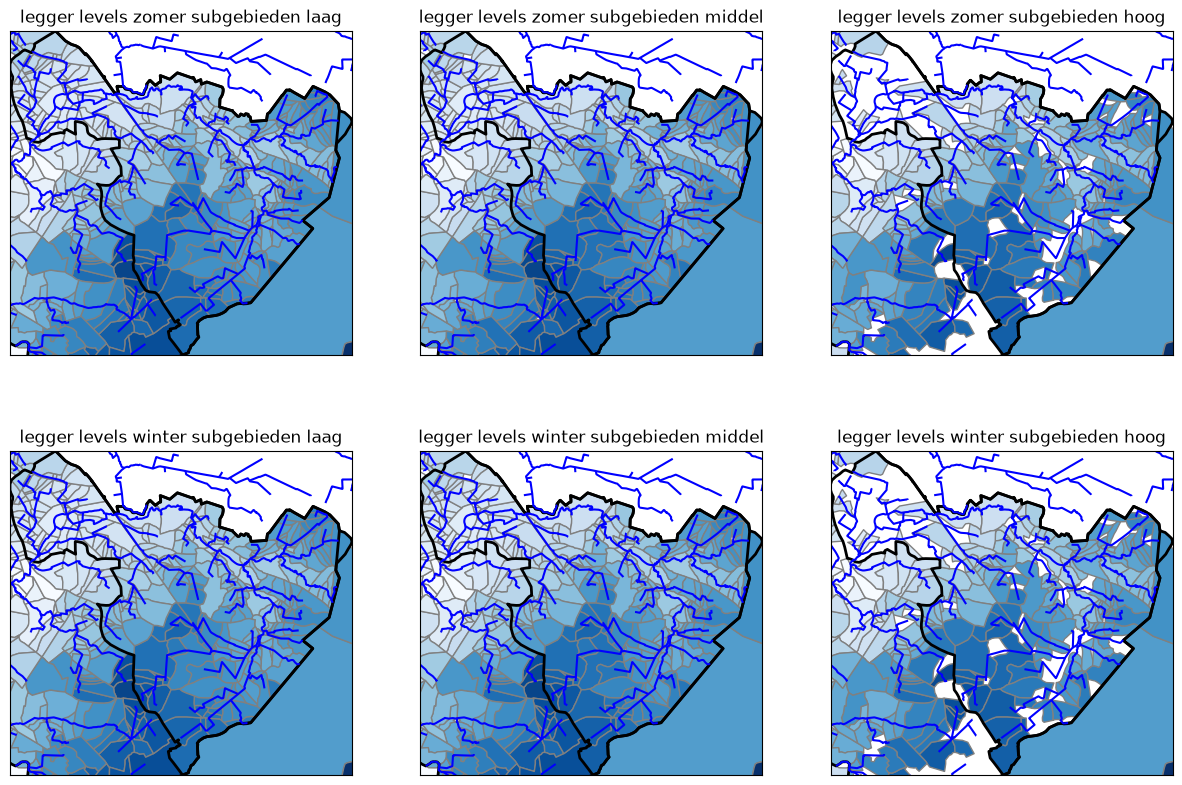

In [105]:
# Create a figure showing the legger levels for zomer and winter for each subgebied (laag/middel/hoog) within the selected project area
sel_gebied = 3
project_area = project_areas.iloc[sel_gebied]

# kaartje voor pilot gebied X
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
xmin,ymin,xmax,ymax = project_area.geometry.bounds

# Loop through each subgebied (laag/middel/hoog) and plot the legger levels for zomer and winter
mapping = {1: "laag", 2: "middel", 3: "hoog"}
for i in [1,2,3]:
    gdf_sel = gdf.loc[gdf.index.get_level_values("hoog_middel_laag") == i]
    for j, seizoen in enumerate(["zomer", "winter"]):
        gdf_sel.plot(
            ax=axs[j, i-1], 
            column=f"legger_level_{seizoen}", 
            edgecolor='grey', 
            cmap="Blues", 
            vmin=30, 
            vmax=50, 
            legend=False
        )
        project_areas.plot(ax=axs[j, i-1], facecolor='none', edgecolor='black', label='Pilotgebieden',linewidth=2)
        watergang.plot(ax=axs[j, i-1], color="blue", label='Watergangen')
        axs[j, i-1].set_title(f"legger levels {seizoen} subgebieden {mapping[i]}")
        axs[j, i-1].set_xlim(round(xmin), round(xmax))
        axs[j, i-1].set_ylim(round(ymin), round(ymax))
        axs[j, i-1].get_xaxis().set_visible(False)
        axs[j, i-1].get_yaxis().set_visible(False)
        # cx.add_basemap(axs[j, i-1], crs=28992, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)

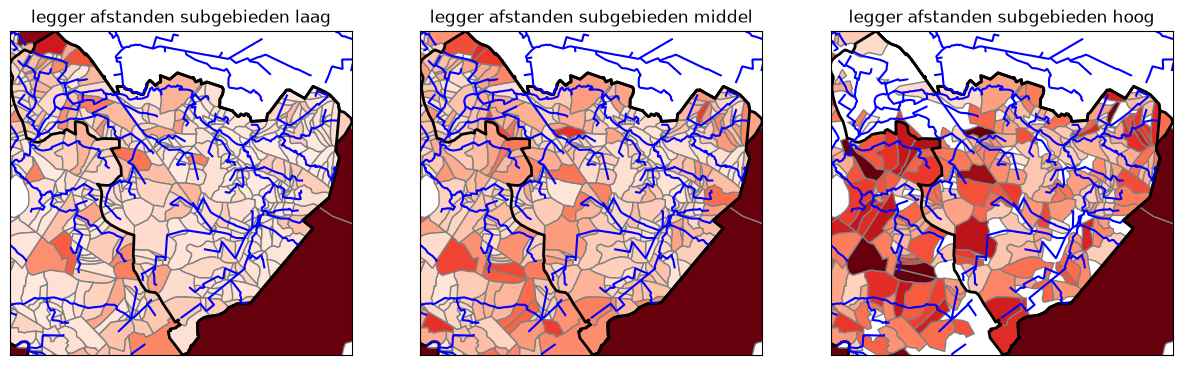

In [106]:
# Create a figure showing the legger afstanden for each subgebied (laag/middel/hoog) within the selected project area
sel_gebied = 3
project_area = project_areas.iloc[sel_gebied]

# kaartje voor pilot gebied X
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
xmin,ymin,xmax,ymax = project_area.geometry.bounds

# Loop through each subgebied (laag/middel/hoog) and plot the legger afstanden
mapping = {1: "laag", 2: "middel", 3: "hoog"}
for i in [1,2,3]:
    gdf_sel = gdf.loc[gdf.index.get_level_values("hoog_middel_laag") == i]
    gdf_sel.plot(
        ax=axs[i-1], 
        column=f"legger_afstand", 
        edgecolor='grey', 
        cmap="Reds", 
        vmin=0, 
        vmax=500, 
        legend=False
    )
    project_areas.plot(ax=axs[i-1], facecolor='none', edgecolor='black', label='Pilotgebieden',linewidth=2)
    watergang.plot(ax=axs[i-1], color="blue", label='Watergangen')
    axs[i-1].set_title(f"legger afstanden subgebieden {mapping[i]}")
    axs[i-1].set_xlim(round(xmin), round(xmax))
    axs[i-1].set_ylim(round(ymin), round(ymax))
    axs[i-1].get_xaxis().set_visible(False)
    axs[i-1].get_yaxis().set_visible(False)
    # cx.add_basemap(axs[i-1], crs=28992, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)

#### Combineren naar Geopackage en CSV

In [107]:
# bereken oppervlakte van elk subgebied (laag/middel/hoog) binnen elke afwateringseenheid
gdf["oppervlakte_subgebied"] = df.groupby(["GFEIDENT_id", "hoog_middel_laag"])["x"].count() * 25.0 * 25.0

In [108]:
# Selecteer een willekeurig punt binnen elk subgebied (laag/middel/hoog) binnen elke afwateringseenheid om de x en y coordinaten te gebruiken voor het genereren van de geometry (points) van het subgebied
df_xy = df.loc[df.groupby(["GFEIDENT_id", "hoog_middel_laag"], group_keys=False).sample(n=1).index][["x", "y"]]
gdf.loc[:, ["x", "y"]] = df_xy.values
gdf.geometry = gpd.points_from_xy(gdf["x"], gdf["y"])

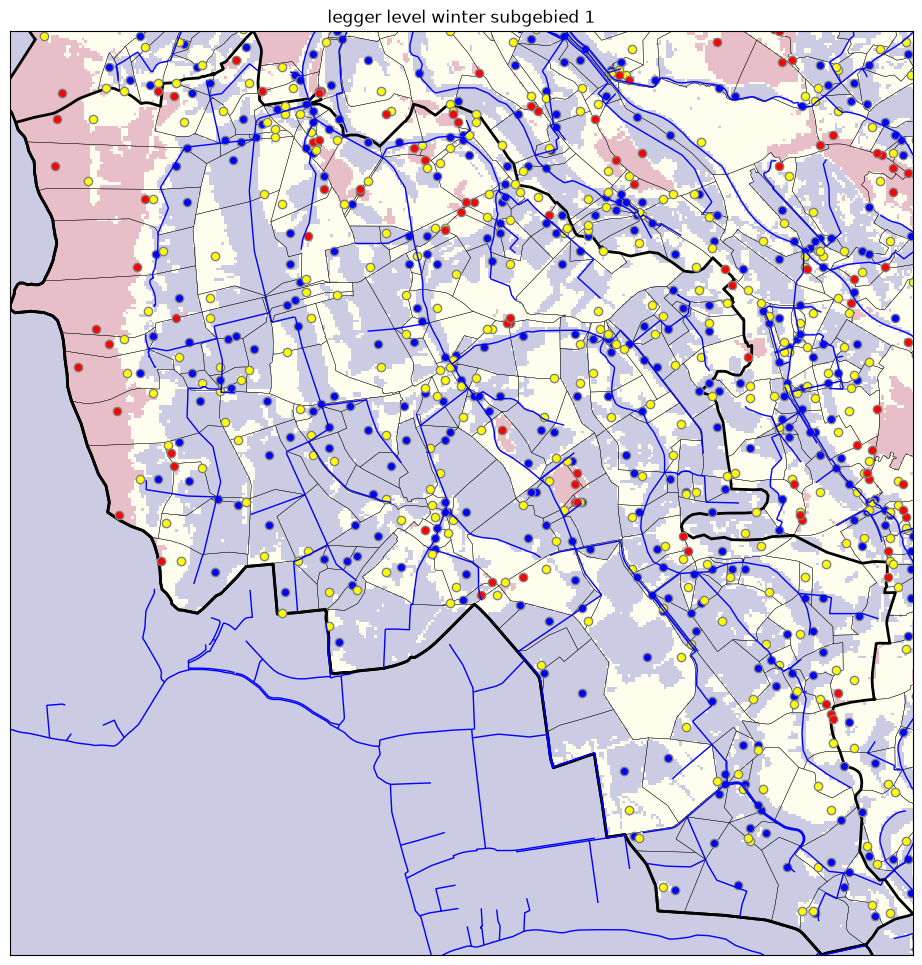

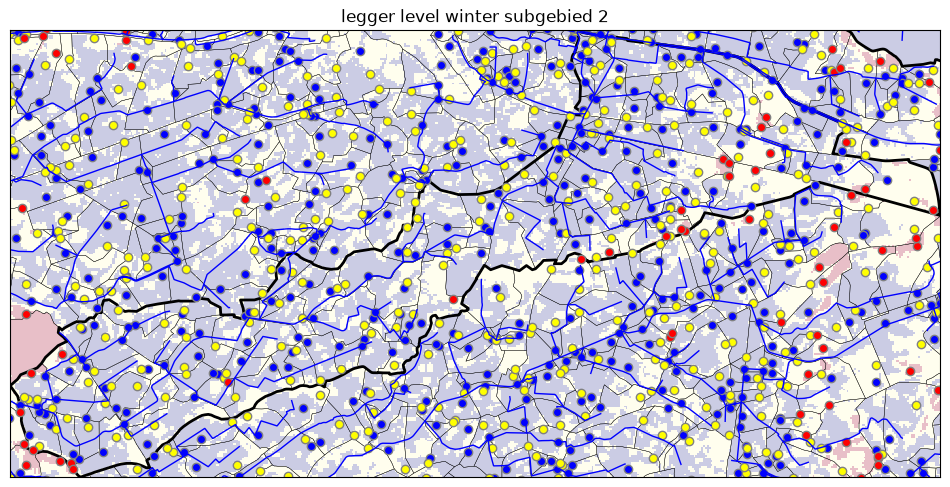

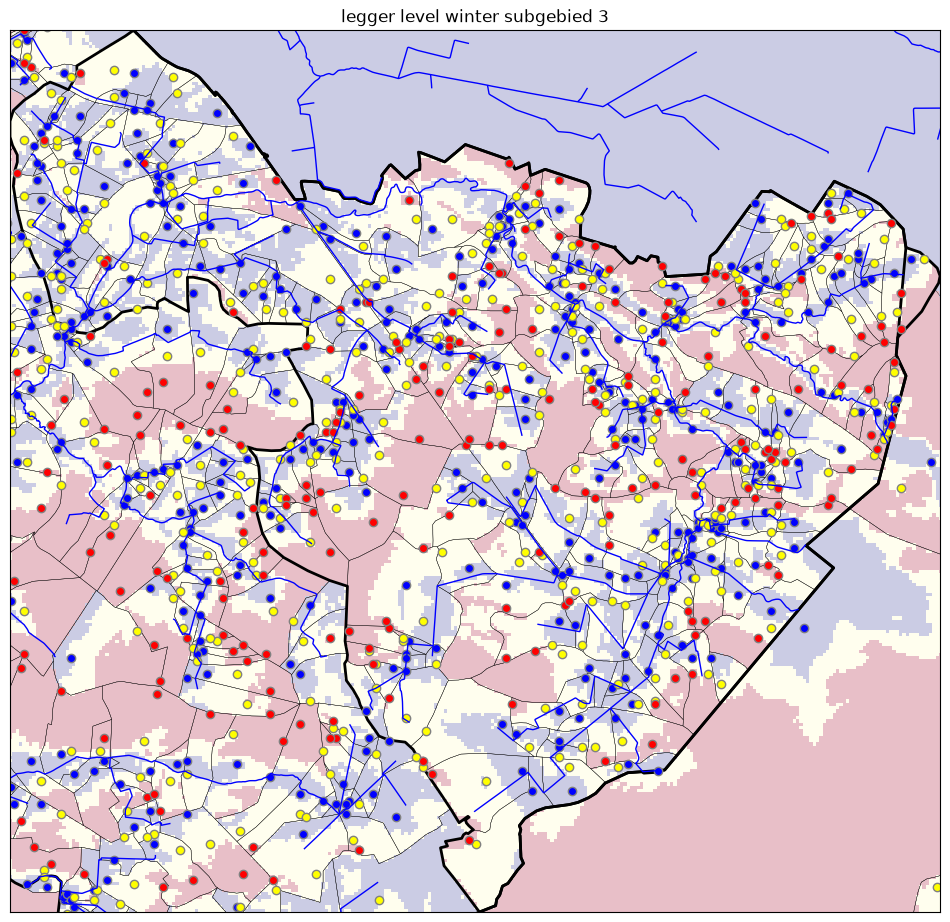

In [109]:
# Create a function to create a figure showing the subgebieden (laag/middel/hoog) for a selected project area
def create_figure_low_middle_high(sel_gebied):

    # select the project area based
    project_area = project_areas.iloc[sel_gebied]

    # kaartje voor pilot gebied 1
    fig, ax = plt.subplots(figsize=(12,12))
    xmin,ymin,xmax,ymax = project_area.geometry.bounds

    # plot de subgebieden, afwateringseenheden, de project area en de watergangen
    ds["hoog_middel_laag"].plot(ax=ax, vmin=1, vmax=3, cmap="RdYlBu_r", add_colorbar=False, alpha=0.25)
    afwateringseenheden.plot(ax=ax, facecolor='none', edgecolor='black', label='afwateringseenheden', linewidth=0.25)
    project_areas.plot(ax=ax, facecolor='none', edgecolor='black', label='Pilotgebieden', linewidth=2)
    watergang.plot(ax=ax, color="blue", label='Watergangen', linewidth=1)

    # plot de punten van de subgebieden (laag/middel/hoog) voor de geselecteerde project area (blue/yellow/red)
    for i, color in zip([1,2,3], ["blue", "yellow", "red"]):
        gdf_sel = gdf.loc[gdf.index.get_level_values("hoog_middel_laag") == i]
        gdf_sel.reset_index().plot(
            ax=ax, 
            facecolor=color,
            edgecolor="grey",
            legend=False
        )

    # set plot settings and add basemap
    ax.set_title(f"legger level {seizoen} subgebied {sel_gebied}")
    ax.set_xlim(round(xmin), round(xmax))
    ax.set_ylim(round(ymin), round(ymax))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # cx.add_basemap(ax, crs=28992, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5)

    # save the figure to a PNG file in the dir_input directory
    fig.savefig(Path(dir_input, f"RR_laag_middel_hoog_gebied_{sel_gebied}"))

# Create figures for the subgebieden (laag/middel/hoog) for each selected project area
for sel_gebied in [1,2,3]:
    create_figure_low_middle_high(sel_gebied)

In [110]:
# Save the gdf to a geopackage and a csv file in the dir_rr_data_scenarios directory
gdf.reset_index().to_file(Path(dir_rr_data_scenarios, scenario, "RR_input_winter_zomer.gpkg"), layer="RR_input_winter_zomer", driver="GPKG")
gdf.reset_index().drop(columns=["geometry"]).to_csv(Path(dir_rr_data_scenarios, scenario, "RR_input_winter_zomer.csv"), index=False)

In [111]:
# Create a dataframe for each season (winter and summer) with the relevant columns for the RR model input
gdf2 = gdf.reset_index()

# Loop through each season (winter and summer) and create a df with the relevant columns for the RR model input
for seizoen in ["winter", "zomer"]:

    # fill the dataframe with the relevant columns for the RR model input
    df_seizoen = pd.DataFrame()
    df_seizoen["xcoor"] = gdf2["x"]
    df_seizoen["ycoor"] = gdf2["y"]
    df_seizoen["GFEIDENT"] = gdf2["GFEIDENT"]
    df_seizoen["GFEIDENT_id"] = gdf2["GFEIDENT_id"]
    df_seizoen["SUBGEBIED"] = gdf2["hoog_middel_laag_str"]
    df_seizoen["SUBGEBIED_id"] = gdf2["hoog_middel_laag"]
    df_seizoen["ID_RR_KNOOP"] = gdf2["RR_code"]
    df_seizoen["SUBMODEL"] = f"{scenario}_{seizoen.upper()}"
    df_seizoen["Area_RR_unpaved_m2"] = gdf2["oppervlakte_subgebied"]
    df_seizoen["CapSimSoilType"] = gdf2["bodemtype_rr"]
    df_seizoen["StorageOnLand_mm"] = gdf2["berging_op_maaiveld_mm"]
    df_seizoen["InfiltrationCapacity_mmph"] = gdf2["infiltratie_mm_uur"]
    df_seizoen["SurfaceLevel_mNAP"] = gdf2["maaiveld"]
    df_seizoen["SurfaceOverlandFlowResistance_d"] = gdf2["oppervlakkige_afstroming_weerstand_d"]

    # Fill the drainage levels and resistances for the first, second, and third drains based on the available data from buisdrainage, top10, and legger levels, with appropriate fallbacks and rounding
    df_seizoen["FirstDrainLevel_mNAP"] = gdf2[f"buisdrainage_level_{seizoen}"].fillna(gdf2["top10_level"]).fillna(gdf2[f"legger_level_{seizoen}"]).round(3)
    df_seizoen["FirstDrainResistance_d"] = gdf2[f"buisdrainage_weerstand_{seizoen}"].fillna(gdf2["top10_weerstand"]).fillna(gdf2[f"legger_weerstand_{seizoen}"]).round(3)
    df_seizoen["SecondDrainLevel_mNAP"] = gdf2[f"buisdrainage_level_{seizoen}"].fillna(gdf2["top10_level"]).fillna(gdf2[f"legger_level_{seizoen}"]).round(3)
    df_seizoen["SecondDrainResistance_d"] = gdf2[f"buisdrainage_weerstand_{seizoen}"].fillna(gdf2["top10_weerstand"]).fillna(gdf2[f"legger_weerstand_{seizoen}"]).round(3)
    df_seizoen["ThirdDrainLevel_mNAP"] = gdf2["top10_level"].fillna(gdf2[f"legger_level_{seizoen}"]).round(3)
    df_seizoen["ThirdDrainResistance_d"] = gdf2["top10_weerstand"].fillna(gdf2[f"legger_weerstand_{seizoen}"]).round(3)
    df_seizoen["OpenWaterLevelBoundary_mNAP"] = gdf2[f"legger_level_{seizoen}"].round(3)
    df_seizoen["OpenWaterDrainResistance_d"] = gdf2[f"legger_weerstand_{seizoen}"].round(3)

    # Set the OpenWaterHorizontalInflowResistance_d to a very high value (10 billion) to effectively prevent horizontal inflow from open water??
    df_seizoen["OpenWaterHorizontalInflowResistance_d"] = 10_000_000_000.0

    # use initial groundwater level from AMIGO if use_amigo_init_gws is True, 
    # otherwise set the initial groundwater level to the minimum of third drain level and the open water level boundary, but at least 0.1 m below the surface level
    if use_amigo_init_gws:
        df_seizoen["InitialGroundwaterLevel_mBelowSurface"] = gdf2["maaiveld"].round(3) - gdf2["initial_gws_head1"].round(3)
    else:
        df_seizoen["InitialGroundwaterLevel_mBelowSurface"] = df_seizoen.apply(
            lambda x: max(min(
                x["SurfaceLevel_mNAP"] - x["ThirdDrainLevel_mNAP"], 
                x["SurfaceLevel_mNAP"] - x["OpenWaterLevelBoundary_mNAP"]
            ), 0.1), axis=1
        ).round(3)

    # fill the remaining columns with default values or values from the gdf2 dataframe
    df_seizoen["LayerThickness_m"] = 5.0
    df_seizoen["MaximumAllowedLevel_mNAP"] = gdf2["maaiveld"]
    df_seizoen["AreaAdjustmentFactor"] = 1.0
    df_seizoen["CropType"] = gdf2["landgebruik_no"]

    # set path and save the dataframe for the current season to a CSV file
    path_RRunpaved_KNOPEN_SCENARIO_SEIZOEN = Path(dir_rr_data_scenarios, scenario, f"RRunpaved_KNOPEN_{scenario}_{seizoen.upper()}.csv")
    df_seizoen.to_csv(path_RRunpaved_KNOPEN_SCENARIO_SEIZOEN, index=False)

    # set path and save the dataframe for the current season with only xcoor, ycoor, and ID_RR_KNOOP to a CSV file (for later use in script RR_01b_genereer_input_seepage.ipynb)
    path_RRunpaved_Gebiedsindeling_RR_KNOPEN = Path(dir_rr_data_scenarios, scenario, f"{scenario}_gebiedsindeling_RR_KNOPEN_tbv_Onderrand.csv")
    df_seizoen[["xcoor", "ycoor", "ID_RR_KNOOP"]].to_csv(path_RRunpaved_Gebiedsindeling_RR_KNOPEN)